# Reinforcement Learning para Mountain Car and Mountain Car continuous

En esta asignación, trabajarás con los entornos de Gymnasium:
- MountainCar-v0
- MountainCarContinuous-v0

Para comparar dos enfoques de aprendizaje por refuerzo:
Q-Learning, ideal para espacios de acción discretos, y Policy
Gradient, que se adapta a espacios de acción continuos.
Implementarás un agente para cada entorno, entrenándolo para
resolver la tarea de llegar a la cima de la colina, y analizarás sus
curvas de aprendizaje, velocidad de convergencia, recompensas
obtenidas y retos encontrados. El objetivo es que observes cómo el
tipo de espacio de acciones influye en el diseño del agente, el
comportamiento del algoritmo y el desempeño final.

## Mountain car discreto con Q learning

This environment is part of the Classic Control environments which contains general information about the environment.

Action Space:

Discrete(3)
- 0: Accelerate to the left
- 1: Don’t accelerate
- 2: Accelerate to the right

Observation Space 

The observation is a ndarray with shape (2,) where the elements correspond to the following:


| Num | Observation | Min | Max | Unit |
| :--- | :--- | :--- | :--- | :--- |
| 0 | position of the car along the x-axis | -1.2 | 0.6 | position (m) |
| 1 | velocity of the car | -0.07 | 0.07 | velocity (v) |


In [33]:
import gymnasium as gym

env = gym.make("MountainCar-v0", render_mode="rgb_array", goal_velocity=0.1)  # default goal_velocity=0
observation, _ = env.reset(seed=42)
print(f"Starting observation: {observation}")
print(f"Action space: {env.action_space}") 
print(f"Sample action: {env.action_space.sample()}")  
print(f"Observation space: {env.observation_space}") 
print(f"Sample observation: {env.observation_space.sample()}") 

Starting observation: [-0.4452088  0.       ]
Action space: Discrete(3)
Sample action: 1
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Sample observation: [-0.845761    0.01534035]


## Implementación del agente

Vamos a implementar Q learning con todas las mejoras hasta este punto:
1. Double Deep Q learning (una red target y una red online para separar objetivos)
La red online se actualiza con su gradiente y es la que se le asigna un optimizador. La red online es la que se usará para seleccionar la acción y la red target es la que se usará para seleccionar el valor con el que actualizar.

2. Un replaybuffer con prioridad para mejorar aprendizaje
Aprendemos por lotes de cierta cantidad de elementos tomados aleatoriamente del historial. En lugar de uno a uno, nos permite modificar más parámetros a la vez.
Este buffer tiene además integrado una prioridad, aprende seleccionando las acciones para las que se tuvo mayor error, o para las que se tomaron más recientemente. El peso de cada muestra cambia segun el numero de pasos.
3. Una estrategia de exploración con epsilon decay
Cambiar epsilon por una estrategia de exploración a explotación al final.

In [159]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import numpy as np

"""
Red Q directamente, dos capas ocultas del tamaño de estados al tamaño de acciones
"""

class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        # Instantiate the first hidden layer
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        # Instantiate the output layer
        self.fc3 = nn.Linear(64, action_size)
    def forward(self, state):
        # Ensure the ReLU activation function is used
        x = torch.relu(self.fc1(torch.tensor(state)))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

"""
El buffer que almacena las experiencias
"""
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001, epsilon=0.01):
        #Armar fila de doble cola
        self.memory = deque(maxlen=capacity)
        self.alpha, self.beta, self.beta_increment, self.epsilon = (alpha, beta, beta_increment, epsilon)
        self.priorities = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        experience_tuple = (state, action, reward, next_state, done)
        # Initialize the transition's priority
        max_priority = max(self.priorities) if self.memory else 1.0
        self.memory.append(experience_tuple)
        self.priorities.append(max_priority)
    
    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors.tolist()):
            # Update the transition's priority
            # De acuerdo con el error y un error para estabilidad numerica
            self.priorities[idx] = abs(td_error)+self.epsilon

    def increase_beta(self):
        # Increase beta if less than 1
        #Beta ajusta el peso de cada experiencia hacia la baja después de cada episodio
        # De esta manera no se sesga la perdida por las experiencias más relevantes
        self.beta = min(1.0, self.beta+self.beta_increment)

    def __len__(self):
        return len(self.memory)

    def sample(self, batch_size):
        priorities = np.array(self.priorities)
        # Calculate the sampling probabilities
        probabilities = priorities**self.alpha / np.sum(priorities**self.alpha)
        # Draw the indices for the sample
        indices = np.random.choice(len(self.memory),batch_size, p=probabilities)
        # Calculate the importance weights
        weights = (1 / (len(self.memory) * probabilities)) ** self.beta
        weights /= np.max(weights)
        states, actions, rewards, next_states, dones = zip(*[self.memory[idx] for idx in indices])
        weights = [weights[idx] for idx in indices]
        states_tensor = torch.tensor(states, dtype=torch.float32)
        rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
        next_states_tensor = torch.tensor(next_states, dtype=torch.float32)
        dones_tensor = torch.tensor(dones, dtype=torch.float32)
        weights_tensor = torch.tensor(weights, dtype=torch.float32)
        actions_tensor = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
        return (states_tensor, actions_tensor, rewards_tensor, next_states_tensor,
                dones_tensor, indices, weights_tensor)

"""
Seleccionar la acción de acuerdo con un cierto epsilon
"""
def select_action(q_values, step, start, end, decay):
    # Calculate the threshold value for this step
    epsilon = end + (start-end) * np.exp(-step / decay)
    # Draw a random number between 0 and 1
    sample = random.random()
    if sample < epsilon:
        # Return a random action index
        return random.choice(range(len(q_values)))
    # Return the action index with highest Q-value
    return torch.argmax(q_values).item()
"""
La red target se actualiza hacia los pesos de la red online pero solo 
respecto a una cierta fracción tau. De esta manera ambos pesos se mantienen separados
pero tendiendo a una misma dirección.
"""

def update_target_network(target_network, online_network, tau):
    # Obtain the state dicts for both networks
    target_net_state_dict = target_network.state_dict()
    online_net_state_dict = online_network.state_dict()
    for key in online_net_state_dict:
        # Calculate the updated state dict for the target network
        target_net_state_dict[key] = (online_net_state_dict[key] * tau + target_net_state_dict[key] * (1-tau))
        # Load the updated state dict into the target network
        target_network.load_state_dict(target_net_state_dict)
    return None

import torch
from collections import defaultdict
"""
funcion para entrenar
"""
def training_DDQN(env, online_network, target_network, optimizer, replay_buffer, episodes=500,
    batch_size=64, gamma=0.99, eps_start=0.9, eps_end=0.1, eps_decay=1000, tau=0.005):
    """
    Double DQN training loop using your helpers:
      - select_action(q_values, step, start, end, decay)
      - update_target_network(target_network, online_network, tau)
      - PrioritizedReplayBuffer with .push/.sample/.update_priorities/.increase_beta()
    Returns: dict with 'rewards', 'steps', 'mean_td_error'
    """
    log_rewards=[]
    log_steps=[]
    log_error=[]
    total_steps = 0
    online_network.train()
    target_network.eval()

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0.0
        ep_steps = 0
        last_td_mean = None

        replay_buffer.increase_beta()
        while not done:
            ep_steps += 1
            total_steps += 1
            # --- act (ε-greedy over online net) ---
            with torch.no_grad(): #no learning in this state, just seeing
                q_vals = online_network(state)
            action = select_action(q_vals, total_steps, start=eps_start, end=eps_end, decay=eps_decay)
            # --- env step ---
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # store
            replay_buffer.push(state, action, reward, next_state, done)
            # --- learn ---
            if len(replay_buffer) >= batch_size:
                states, actions, rewards, next_states, dones, idxs, weights = replay_buffer.sample(batch_size)
                # Q(s,a; θ)
                q_sa = online_network(states).gather(1, actions).squeeze(1)
                # ----- Double DQN target -----
                with torch.no_grad():
                    # action selection with online net
                    next_acts = online_network(next_states).argmax(dim=1, keepdim=True)   # (B,1)
                    # evaluation with target net
                    next_q_target = target_network(next_states).gather(1, next_acts).squeeze(1)  # (B,)
                    target = rewards + gamma * next_q_target * (1.0 - dones)

                td_errors = target - q_sa
                # Update the replay buffer priorities for that batch
                replay_buffer.update_priorities(idxs, td_errors)
                loss = torch.sum(weights * (q_sa - target) ** 2) # / weights.sum()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                # soft target update
                update_target_network(target_network, online_network, tau)
                last_td_mean = td_errors.abs().mean().item()
            state = next_state
            ep_reward += reward

        
        log_rewards.append(ep_reward)
        log_steps.append(ep_steps)
        log_error.append(last_td_mean)

    return log_rewards,log_steps,log_error


In [160]:
import gymnasium as gym
env = gym.make("MountainCar-v0", render_mode="rgb_array")  # default goal_velocity=0
state_size = 2
action_size = 3


online_network= QNetwork(state_size=state_size,action_size=action_size)
target_network= QNetwork(state_size=state_size,action_size=action_size)
replay_buffer = PrioritizedReplayBuffer(capacity=20000, alpha=0.6,
                beta=0.4, beta_increment=0.001, epsilon=0.01)
update_target_network(target_network, online_network, 1)
optimizer = optim.Adam(online_network.parameters(), lr=0.01)
print("online network weights:", online_network.state_dict()['fc1.weight'][0])
print("target network weights (post-update):",target_network.state_dict()['fc1.weight'][0])

online network weights: tensor([ 0.4421, -0.6382])
target network weights (post-update): tensor([ 0.4421, -0.6382])


In [163]:
episodes= 3000
optimizer = optim.Adam(online_network.parameters(), lr=0.001)

batch_size=64
tau= 0.005
gamma=0.99
log_rewards,log_steps,log_error = training_DDQN(
    env=env,
    online_network=online_network,
    target_network=target_network,
    optimizer=optimizer,
    replay_buffer=replay_buffer,
    episodes=episodes,
    batch_size=batch_size,
    gamma=gamma,
    eps_start=0.95,
    eps_end=0.05,
    eps_decay=20000,
    tau=tau,
)

print("Last 10 episode rewards:", log_rewards)

C:\Users\disom\AppData\Local\Temp\ipykernel_28484\3003249943.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.relu(self.fc1(torch.tensor(state)))


Last 10 episode rewards: [-200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0, -200.0

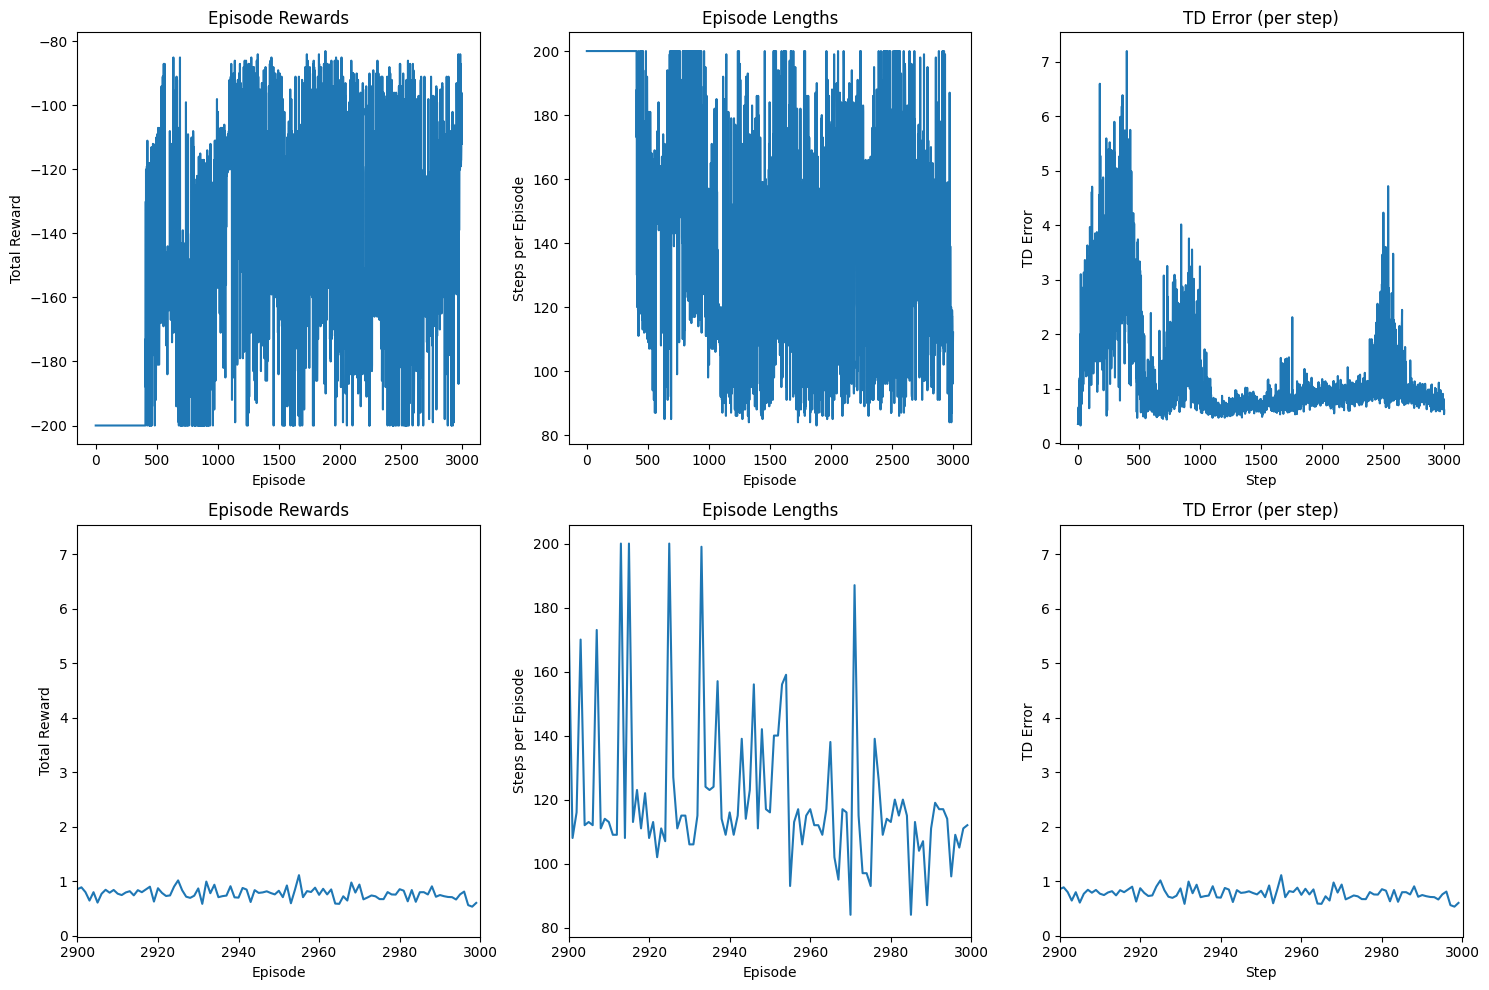

In [164]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10),sharex=False)

# Episodic rewards
axs[0,0].set_title("Episode Rewards")
axs[0,0].plot(log_rewards)
axs[0,0].set_ylabel("Total Reward")
axs[0,0].set_xlabel("Episode")

# Episode lengths
axs[0,1].set_title("Episode Lengths")
axs[0,1].plot(log_steps)
axs[0,1].set_ylabel("Steps per Episode")
axs[0,1].set_xlabel("Episode")

# Temporal Difference Error
axs[0,2].set_title("TD Error (per step)")
axs[0,2].plot(log_error)
axs[0,2].set_ylabel("TD Error")
axs[0,2].set_xlabel("Step")


# Episodic rewards
axs[1,0].set_title("Episode Rewards")
axs[1,0].plot(log_error)
axs[1,0].set_ylabel("Total Reward")
axs[1,0].set_xlabel("Episode")
axs[1,0].set_xlim(len(log_error)-100,len(log_error))
#axs[1,0].set_ylim(-50,+50)

# Episode lengths
axs[1,1].set_title("Episode Lengths")
axs[1,1].plot(log_steps)
axs[1,1].set_ylabel("Steps per Episode")
axs[1,1].set_xlabel("Episode")
axs[1,1].set_xlim(len(log_steps)-100,len(log_steps))
#axs[1,1].set_ylim(0,40)

# Temporal Difference Error
axs[1,2].set_title("TD Error (per step)")
axs[1,2].plot(log_error)
axs[1,2].set_ylabel("TD Error")
axs[1,2].set_xlabel("Step")
axs[1,2].set_xlim(len(log_error)-100,len(log_error))
#axs[1,2].set_ylim(0,15)

plt.tight_layout()
plt.show()


Avg reward over 200 eps: -105.97
Avg steps  over 200 eps: 106.0
Avg mean |TD error|      : 0.4090


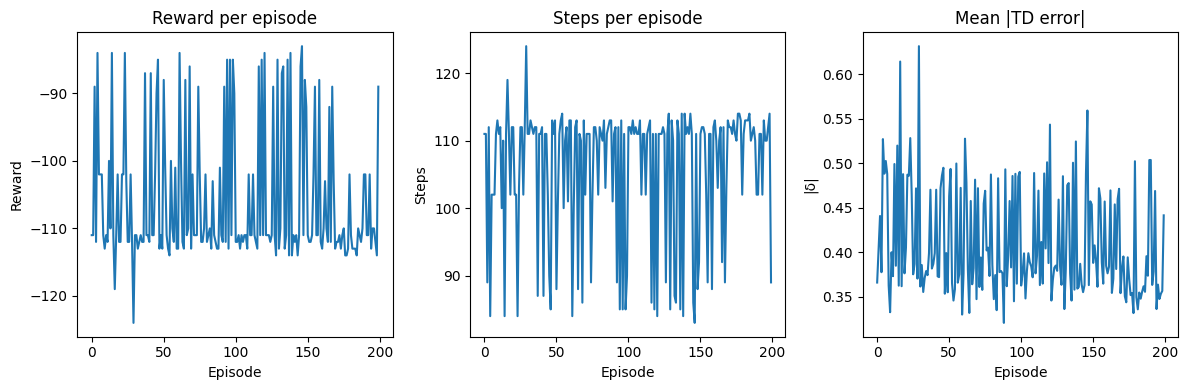

In [165]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_agent(env, online_network, target_network, episodes=200, gamma=0.99):
    online_network.eval()
    target_network.eval()

    ep_rewards, ep_steps, ep_td_err = [], [], []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0.0
        steps = 0
        td_errors = []

        with torch.no_grad():
            while not done:
                # Greedy action (no exploration) for evaluation
                q_vals = online_network(state)
                action = torch.argmax(q_vals).item()

                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                # TD error for logging (no learning):
                q_sa = q_vals[action].item()
                next_q_max = target_network(next_state).amax().item()
                target = reward + gamma * next_q_max * (0.0 if done else 1.0)
                td_errors.append(abs(target - q_sa))

                total_reward += reward
                steps += 1
                state = next_state

        ep_rewards.append(total_reward)
        ep_steps.append(steps)
        ep_td_err.append(float(np.mean(td_errors)) if td_errors else 0.0)

    return {"rewards": ep_rewards, "steps": ep_steps, "td_error": ep_td_err}

# ---- run it ----
N_EPISODES = 200
logs = evaluate_agent(env, online_network, target_network, episodes=N_EPISODES, gamma=gamma)

print(f"Avg reward over {N_EPISODES} eps: {np.mean(logs['rewards']):.2f}")
print(f"Avg steps  over {N_EPISODES} eps: {np.mean(logs['steps']):.1f}")
print(f"Avg mean |TD error|      : {np.mean(logs['td_error']):.4f}")

# ---- quick plots ----
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(logs["rewards"]); axs[0].set_title("Reward per episode"); axs[0].set_xlabel("Episode"); axs[0].set_ylabel("Reward")
axs[1].plot(logs["steps"]);   axs[1].set_title("Steps per episode");  axs[1].set_xlabel("Episode"); axs[1].set_ylabel("Steps")
axs[2].plot(logs["td_error"]);axs[2].set_title("Mean |TD error|");    axs[2].set_xlabel("Episode"); axs[2].set_ylabel("|δ|")
plt.tight_layout(); plt.show()

Con DDQN se logra llegar a menos de 200 pasos en cada episodio.

## Mountain car continuo con policy gradient

This environment is part of the Classic Control environments which contains general information about the environment. It has now a continuous action space.

Action Space, continuous:
The action is a ndarray with shape (1,), representing the directional force applied on the car. The action is clipped in the range [-1,1] and multiplied by a power of 0.0015.

Observation Space 
The observation is a ndarray with shape (2,) where the elements correspond to the following:


| Num | Observation | Min | Max | Unit |
| :--- | :--- | :--- | :--- | :--- |
| 0 | position of the car along the x-axis | -1.2 | 0.6 | position (m) |
| 1 | velocity of the car | -0.07 | 0.07 | velocity (v) |


In [103]:
import gymnasium as gym

env_2 = gym.make("MountainCarContinuous-v0")  # default goal_velocity=0
observation, _ = env_2.reset(seed=42)
print(f"Starting observation: {observation}")
print(f"Action space: {env_2.action_space}") 
print(f"Sample action: {env_2.action_space.sample()}")  
print(f"Observation space: {env_2.observation_space}") 
print(f"Sample observation: {env_2.observation_space.sample()}") 

Starting observation: [-0.4452088  0.       ]
Action space: Box(-1.0, 1.0, (1,), float32)
Sample action: [-0.20401928]
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Sample observation: [-0.8601611   0.04412477]


## Implementación del agente

Se hace el agente básico de policy gradient. Como tenemos un espacio de accion continuo, muestreamos los parámetros de una distribución normal para elegir la acción.
La red aprende los parámetros con los que muestreará la solución en función del estado alimentado, y luego esa solución la reescala hacia el campo adecuado. Se hace promedio cada 10 episodios para obtener el gradiente.

In [104]:
import torch
import torch.nn as nn
from torch.distributions import Normal

class GaussianPolicy1D(nn.Module):
    def __init__(self, state_size, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(state_size, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.mu_head = nn.Linear(hidden, 1)         # mean for 1-D action
        self.log_std = nn.Parameter(torch.zeros(1)) # learn a global log-std (simplest)

    def forward(self, state):
        x = torch.as_tensor(state, dtype=torch.float32)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        mu = self.mu_head(x).squeeze(-1)            # shape: ()
        std = torch.exp(self.log_std)               # positive
        return mu, std
  
def sample_action_and_logprob(policy, state):
    mu, std = policy(state)                         # scalars (0-dim tensors) for 1-D action
    dist = Normal(mu, std)
    # Reparameterized sample
    z = dist.rsample()                              # pre-squash action
    a = torch.tanh(z)                               # squash to (-1,1)
    # log_prob with tanh correction: log π(a) = log N(z; μ,σ) - log(1 - tanh(z)^2)
    # small epsilon for numerical stability
    log_prob = dist.log_prob(z) - torch.log(1 - a.pow(2) + 1e-6)
    # Gym expects numpy array shape (1,)
    action_np = a.detach().numpy().reshape(1,)
    return action_np, log_prob  # log_prob is a scalar tensor

def train_policy_gradient_continuous(env, 
    policy, optimizer, episodes=200, batch_episodes=10, gamma=0.99):
    policy.train()
    ep_rewards, ep_steps, ep_errors = [], [], []
    batch_returns = []
    batch_logprob_sums = []

    def finish_update():
        if not batch_returns:
          return None
        R = torch.tensor(batch_returns, dtype=torch.float32)
        L = -(R * torch.stack(batch_logprob_sums)).mean()
        optimizer.zero_grad()
        L.backward()
        optimizer.step()
        batch_returns.clear()
        batch_logprob_sums.clear()

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        G = 0.0
        t = 0
        logprob_sum = torch.tensor(0.0)
        ep_ret = 0.0
        steps = 0

        while not done:
            steps += 1
            t += 1
            action, log_prob = sample_action_and_logprob(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_ret += reward
            logprob_sum = logprob_sum + log_prob
            G += (gamma ** (t - 1)) * reward
            state = next_state

        ep_rewards.append(ep_ret)
        ep_steps.append(steps)
        ep_errors.append(float(-(G) * logprob_sum.detach()))

        batch_returns.append(G)
        batch_logprob_sums.append(logprob_sum)

        if (ep + 1) % batch_episodes == 0:
            finish_update()

    finish_update()
    return {"rewards": ep_rewards, "steps": ep_steps, "errors": ep_errors}


In [168]:
state_size_2=2
hidden=64
batch_episodes=10
gamma_2=0.99
policy_network = GaussianPolicy1D(state_size=state_size_2,hidden=hidden)
env_2 = gym.make("MountainCarContinuous-v0")  # default goal_velocity=0
log_2={}


In [171]:
optimizer = optim.Adam(policy_network.parameters(), lr=0.001)
episodes=1500
log_2=(train_policy_gradient_continuous(env_2, 
    policy_network, optimizer, episodes=episodes,
    batch_episodes=batch_episodes, gamma=gamma_2))

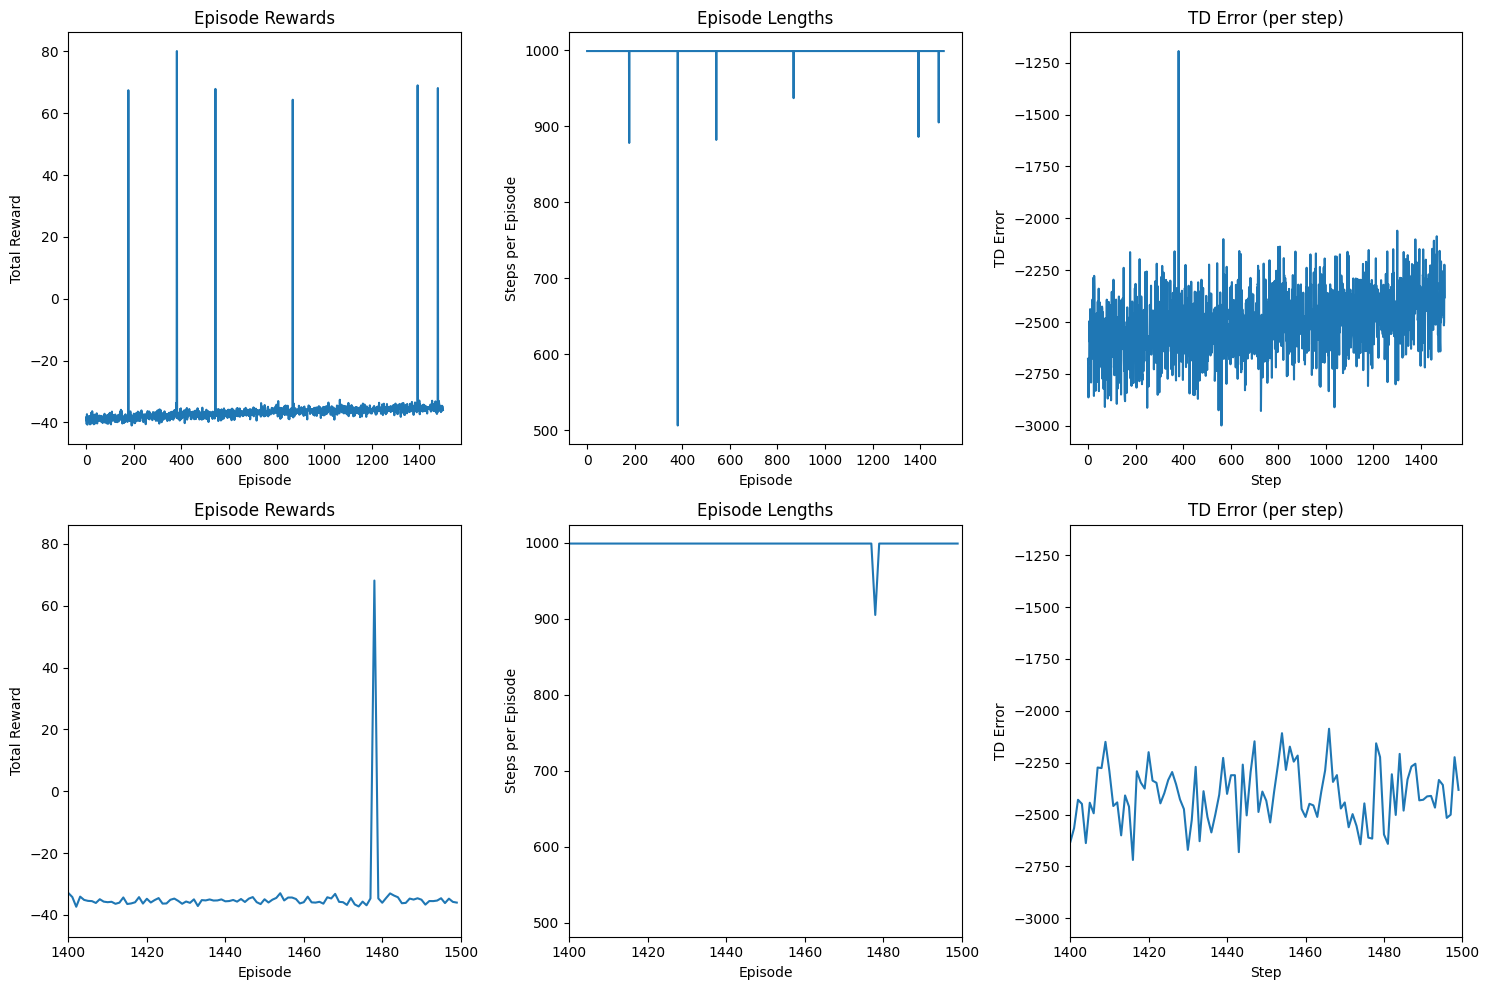

In [172]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10),sharex=False)

# Episodic rewards
axs[0,0].set_title("Episode Rewards")
axs[0,0].plot(log_2["rewards"])
axs[0,0].set_ylabel("Total Reward")
axs[0,0].set_xlabel("Episode")

# Episode lengths
axs[0,1].set_title("Episode Lengths")
axs[0,1].plot(log_2["steps"])
axs[0,1].set_ylabel("Steps per Episode")
axs[0,1].set_xlabel("Episode")

# Temporal Difference Error
axs[0,2].set_title("TD Error (per step)")
axs[0,2].plot(log_2["errors"])
axs[0,2].set_ylabel("TD Error")
axs[0,2].set_xlabel("Step")


# Episodic rewards
axs[1,0].set_title("Episode Rewards")
axs[1,0].plot(log_2["rewards"])
axs[1,0].set_ylabel("Total Reward")
axs[1,0].set_xlabel("Episode")
axs[1,0].set_xlim(len(log_2["rewards"])-100,len(log_2["rewards"]))
#axs[1,0].set_ylim(-50,+50)

# Episode lengths
axs[1,1].set_title("Episode Lengths")
axs[1,1].plot(log_2["steps"])
axs[1,1].set_ylabel("Steps per Episode")
axs[1,1].set_xlabel("Episode")
axs[1,1].set_xlim(len(log_2["steps"])-100,len(log_2["steps"]))
#axs[1,1].set_ylim(0,40)

# Temporal Difference Error
axs[1,2].set_title("TD Error (per step)")
axs[1,2].plot(log_2["errors"])
axs[1,2].set_ylabel("TD Error")
axs[1,2].set_xlabel("Step")
axs[1,2].set_xlim(len(log_2["errors"])-100,len(log_2["errors"]))
#axs[1,2].set_ylim(0,15)

plt.tight_layout()
plt.show()

Avg reward over 50 eps: -35.18
Avg steps  over 50 eps: 999.0
Avg mean NLL (uncertainty): 0.6835


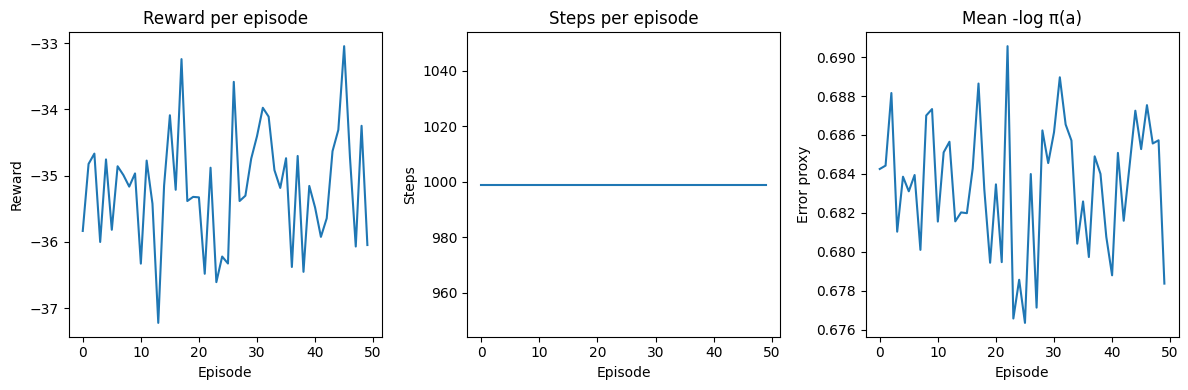

In [173]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def evaluate_gaussian_policy(env, policy_network, episodes=20, gamma=0.99):
    policy_network.eval()
    ep_rewards, ep_steps, ep_errors = [], [], []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward, steps = 0.0, 0
        log_probs = []

        with torch.no_grad():
            while not done:
                mu, std = policy_network(state)
                dist = torch.distributions.Normal(mu, std)
                z = dist.sample()
                action = torch.tanh(z)  # squash to (-1,1)
                
                # Log prob with tanh correction
                log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
                log_probs.append(-log_prob.item())  # negative log-prob as "error"

                next_state, reward, terminated, truncated, _ = env.step(action.cpu().numpy().reshape(1,))
                done = terminated or truncated

                total_reward += reward
                steps += 1
                state = next_state

        ep_rewards.append(total_reward)
        ep_steps.append(steps)
        ep_errors.append(np.mean(log_probs))

    return {"rewards": ep_rewards, "steps": ep_steps, "errors": ep_errors}

# ---- run it ----
N_EPISODES = 50
logs2 = evaluate_gaussian_policy(env_2, policy_network, episodes=N_EPISODES, gamma=gamma_2)

print(f"Avg reward over {N_EPISODES} eps: {np.mean(logs2['rewards']):.2f}")
print(f"Avg steps  over {N_EPISODES} eps: {np.mean(logs2['steps']):.1f}")
print(f"Avg mean NLL (uncertainty): {np.mean(logs2['errors']):.4f}")

# ---- quick plots ----
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(logs2["rewards"]); axs[0].set_title("Reward per episode"); axs[0].set_xlabel("Episode"); axs[0].set_ylabel("Reward")
axs[1].plot(logs2["steps"]);   axs[1].set_title("Steps per episode");  axs[1].set_xlabel("Episode"); axs[1].set_ylabel("Steps")
axs[2].plot(logs2["errors"]);  axs[2].set_title("Mean -log π(a)");     axs[2].set_xlabel("Episode"); axs[2].set_ylabel("Error proxy")
plt.tight_layout(); plt.show()


Aunque Policy gradiente si demuestra una mejora respecto a la recompensa, no logré llegar al final de su entrenamiento para un resultado satisfactorio.